# 1 Module, Globals und Daten


## 1.1 Module


In [69]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

import sklearn.metrics as skm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import os

import matplotlib.pyplot as pyplot

## 1.2 Globals

In [70]:
dataPath = 'datasets/mushroom/'                         # Set location of dataset

## 1.3 Daten

In [ ]:
data = pd.read_csv(dataPath + 'secondary_mushroom.csv', sep=";")    # Dataset is imbalanced with only ~1.7% of all labels being 0's
xdata = data.iloc[:,:20]
ydata = data.iloc[:,20:]    # Classratio 9:11


## 1.4 Pre-Processing

### 1.4.1 Functions for 2 different encoding methods

In [72]:
def encodeLabels():
    encoders = {}

    # Create a list with the names of all columns, that contain categorical data
    xdata_cats = list(xdata.columns)
    [xdata_cats.remove(i) for i in ['cap-diameter','stem-height','stem-width']]

    # Encode all categorical feature-labels and save encoders in a dictionary
    for cat in xdata_cats:
        le = LabelEncoder()
        xdata[cat] = le.fit_transform(xdata[cat])
        encoders.update({cat:le})

    le = LabelEncoder()
    ydata['class'] = le.fit_transform(ydata['class'])
    encoders.update({'class':le})

    return encoders

def encodeOHE():
    xdata_categorical = xdata.copy()
    numeric_features = ['cap-diameter','stem-height','stem-width']

    for i in numeric_features:
        xdata_categorical = xdata_categorical.drop(i,axis=1) 

    xdata_numeric = pd.DataFrame()
    for feat in numeric_features:
        xdata_numeric[feat] = xdata[feat]

    ohe = OneHotEncoder()
    ohedata = ohe.fit_transform(xdata_categorical)

    xdata_categorical_ohe = pd.DataFrame(ohedata.toarray(), columns=ohe.get_feature_names_out(), dtype=int)

    xdata_encoded = pd.concat([xdata_numeric, xdata_categorical_ohe],axis=1)

    yEncoder = LabelEncoder()
    ydata['class'] = yEncoder.fit_transform(ydata['class'])

    return xdata_encoded, yEncoder

### 1.4.2 Encoding Function Calls

In [73]:
# encodeLabels()
xdata, yEncoder = encodeOHE() # Weil keine Rangfolge zwischen den einzelnen Kategorien herrscht, wird OHE angewendet

### 1.4.3 Data Splitting

In [74]:
xtrain, xtest, ytrain, ytest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.33,
    stratify=ydata
)

ev_test = [(xtest,ytest)]
ev_both = [(xtest,ytest),(xtrain,ytrain)]

## 1.5 Funktionen

In [ ]:
def plotReport(model):
    global xtest, ytest
    yhat = model.predict(xtest)
    print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
    print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
    print()
    print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='true')
    pyplot.title('')
    pyplot.show()

    skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap="Blues" ,values_format='d')
    pyplot.show()

def plotLearningCurves(model):
    
    # https://xgboosting.com/xgboost-plot-learning-curve/

    global xtest, ytest
    
    # Calculate learning curves
    train_sizes, train_scores, test_scores = learning_curve(
    estimator=model, X=xdata, y=ydata, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.75, 1.0, 10))

    # Calculate mean and standard deviation of scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot learning curves
    pyplot.figure(figsize=(8, 6))
    pyplot.plot(train_sizes, train_mean, color='blue', marker='o', label='Training accuracy')
    pyplot.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    pyplot.plot(train_sizes, test_mean, color='green', marker='+', label='Validation accuracy')
    pyplot.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')
    pyplot.title('Learning Curves')
    pyplot.xlabel('Training set size')
    pyplot.ylabel('Accuracy')
    pyplot.grid()
    pyplot.legend(loc='lower right')
    pyplot.show()

def plotFeatureImportances(model):    
    iScores = model.feature_importances_
    fNames = model.feature_names_in_

    fig,ax = pyplot.subplots()
    ax.bar(fNames, iScores)
    ax.set_ylabel("Importance Scores")
    ax.set_xlabel("Features")

    pyplot.show()

def plotGeneralizationCurves(model, custom_names = None):
    results = model.evals_result()
    names = list(model.evals_result())
    lossValue = list(results[names[0]])[0]
    
    if custom_names == None:
        for i in names:
            pyplot.plot(results[i][lossValue], label=i)
    else:
        name_index = 0
        for i in names:
            pyplot.plot(results[i][lossValue], label=custom_names[name_index])
            name_index += 1

    pyplot.ylabel(lossValue)
    pyplot.xlabel('Iterations')
    pyplot.legend()
    pyplot.show()

def checkOverfitting(model):
    global xtrain, ytrain, xtest, ytest
    print("Flat Scores:")
    train_acc = skm.accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}\n')

    print("Balanced Scores:")
    train_acc = skm.balanced_accuracy_score(ytrain, model.predict(xtrain))
    test_acc = skm.balanced_accuracy_score(ytest, model.predict(xtest))
    print(f'Accuracy Score mit Trainings-Datensatz: {train_acc}')
    print(f'Accuracy Score mit Test-Datensatz: {test_acc}')
    print(f'Train-Test-Difference: {train_acc - test_acc}')

# 2 Modell

## 2.1 Best Iteration finden


Best Iteration based on Test-Data: 1782
Accuracy Score: 		0.9997800425251118
Balanced Accuracy-Score: 	0.999769208702631

              precision    recall  f1-score   support

 0: standing       1.00      1.00      1.00     18212
  1: walking       1.00      1.00      1.00     22705

    accuracy                           1.00     40917
   macro avg       1.00      1.00      1.00     40917
weighted avg       1.00      1.00      1.00     40917



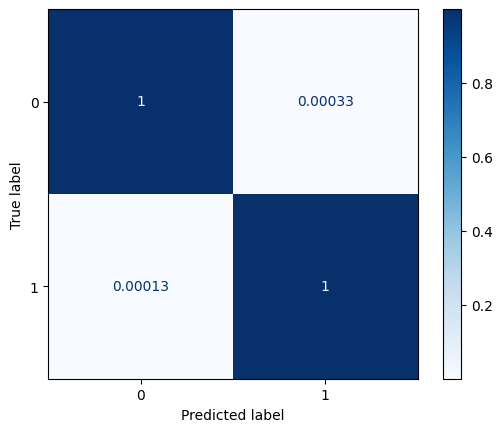

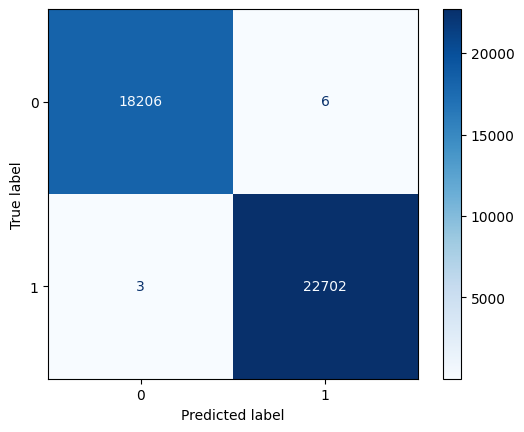

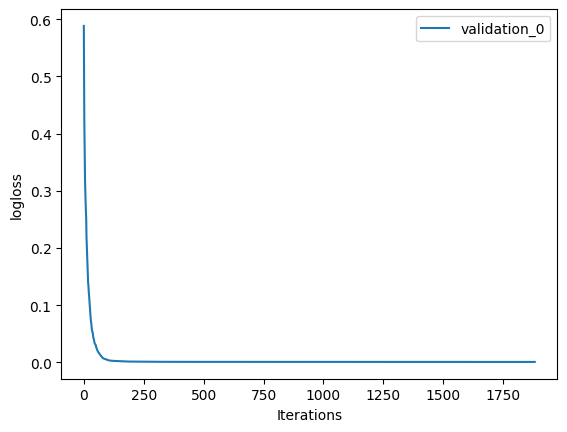

Accuracy Score: 		0.9997800425251118
Balanced Accuracy-Score: 	0.999769208702631

              precision    recall  f1-score   support

 0: standing       1.00      1.00      1.00     18212
  1: walking       1.00      1.00      1.00     22705

    accuracy                           1.00     40917
   macro avg       1.00      1.00      1.00     40917
weighted avg       1.00      1.00      1.00     40917



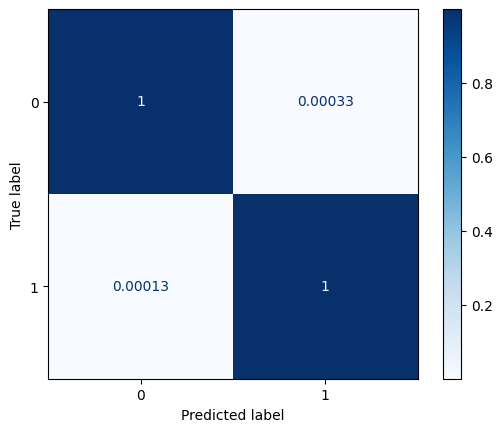

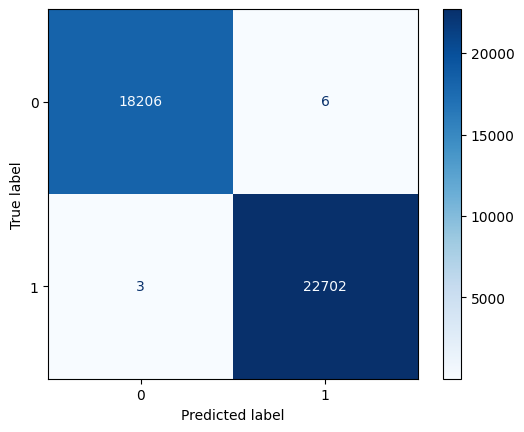

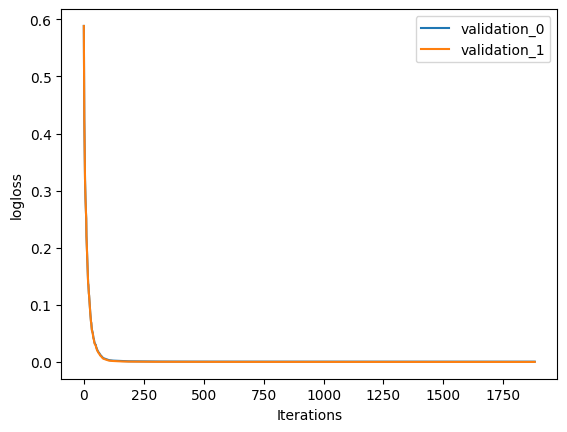

Train-Test-Difference: 0.0002199574748882327


In [ ]:
clf_vanilla = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    n_estimators = 100000,
    early_stopping_rounds = 100,
)

clf_vanilla.fit(xtrain,ytrain,
               eval_set=ev_test,
               verbose = 0)

print(f'Best Iteration based on Test-Data: {clf_vanilla.best_iteration}')
plotReport(clf_vanilla)
plotGeneralizationCurves(clf_vanilla)

new_n_estimators = clf_vanilla.early_stopping_rounds + clf_vanilla.best_iteration
bestIteration = clf_vanilla.best_iteration

clf_vanilla.set_params(
    n_estimators = new_n_estimators,
    early_stopping_rounds = None
)
clf_vanilla.fit(
    xtrain, ytrain,
    eval_set = ev_both,
    verbose = 0
)

plotReport(clf_vanilla)
plotGeneralizationCurves(clf_vanilla)
checkOverfitting(clf_vanilla)

## 2.2 Modellverhalten bei variierender Baumtiefe untersuchen


In [79]:
bestIterList = []
accList = []
ubjSizeList = []
jsonSizeList = []

for i in range(1,16):
    clf_iter = XGBClassifier(objective = "binary:logistic",
                             tree_method = 'exact',
                             n_estimators = 100000,
                             early_stopping_rounds = 50,
                             max_depth = i
                             )

    clf_iter.fit(xtrain,ytrain,
                 eval_set=ev_test,
                 verbose = 0
                 )

    bestIter_local = clf_iter.best_iteration
    acc_local = skm.accuracy_score(ytest,clf_iter.predict(xtest, iteration_range=(0,clf_iter.best_iteration)))
    
    clf_iter = XGBClassifier(objective = "binary:logistic",
                            tree_method = 'exact',
                            n_estimators = bestIter_local,
                            early_stopping_rounds = None,
                            max_depth = i
                            )

    clf_iter.fit(xtrain,ytrain,
                eval_set=ev_test,
                verbose = 0
                )

    clf_iter.save_model('clf_iter.ubjson')
    clf_iter.save_model('clf_iter.json')
    
    ubjSizeList.append(os.path.getsize('clf_iter.ubjson'))
    jsonSizeList.append(os.path.getsize('clf_iter.json'))
    bestIterList.append(bestIter_local)
    accList.append(acc_local)

/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [20:53:44] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [20:54:11] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [20:54:29] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
/home/denis/arduino-xgboost/.venv/lib/py

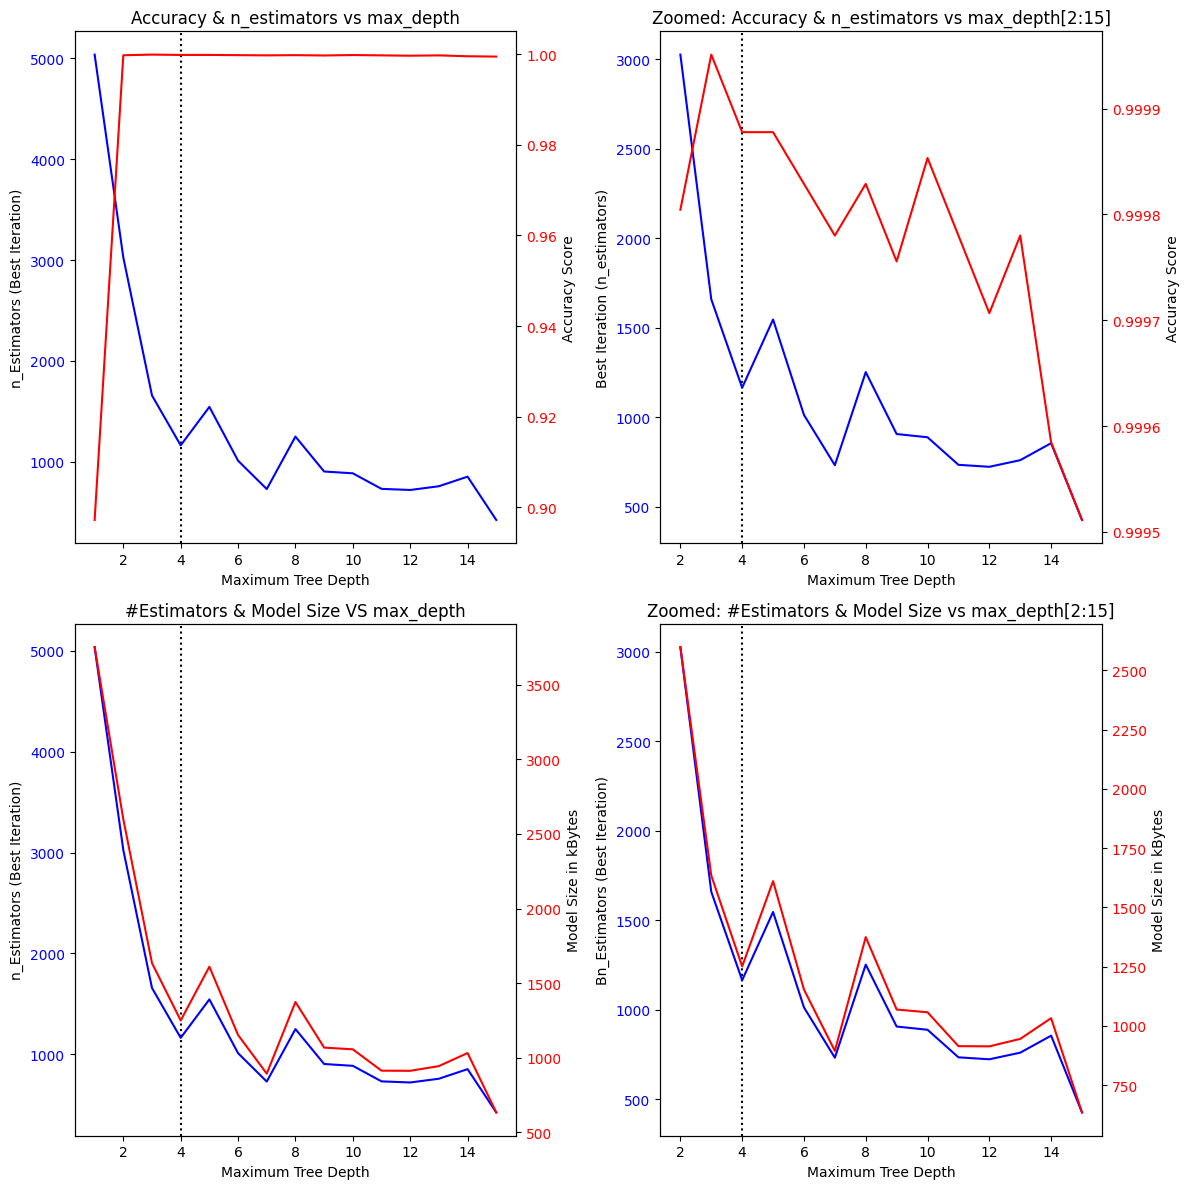

In [81]:
# Plot Accuracy vs Complexity

ubjSizeList_kB = [x/1024 for x in ubjSizeList]

fig, ax = pyplot.subplots(2,2)

fig.set_figwidth(12)
fig.set_figheight(12)

##### OBEN LINKS #####

ax[0][0].set_title("Accuracy & n_estimators vs max_depth")

ax[0][0].axvline(x=4, color="black", linestyle=":")

ax[0][0].set_xlabel("Maximum Tree Depth")
ax[0][0].set_ylabel("n_Estimators (Best Iteration)")
ax[0][0].tick_params(axis='y', labelcolor="blue")
ax[0][0].plot(range(1,16),bestIterList,color="blue")

ax10_twin = ax[0][0].twinx()

ax10_twin.set_ylabel("Accuracy Score")
ax10_twin.tick_params(axis='y', labelcolor="red")
ax10_twin.plot(range(1,16),accList,color="red")

##### OBEN RECHTS #####

ax[0][1].set_title("Zoomed: Accuracy & n_estimators vs max_depth[2:15]")

ax[0][1].axvline(x=4, color="black", linestyle=":")

ax[0][1].set_xlabel("Maximum Tree Depth")
ax[0][1].set_ylabel("Best Iteration (n_estimators)")
ax[0][1].tick_params(axis='y', labelcolor="blue")
ax[0][1].plot(range(2,16),bestIterList[1:],color="blue")

ax11_twin = ax[0][1].twinx()

ax11_twin.set_ylabel("Accuracy Score")
ax11_twin.tick_params(axis='y', labelcolor="red")
ax11_twin.plot(range(2,16),accList[1:],color="red")

##### UNTEN LINKS #####

ax[1][0].set_title("#Estimators & Model Size VS max_depth")

ax[1][0].axvline(x=4, color="black", linestyle=":")

ax[1][0].set_xlabel("Maximum Tree Depth")
ax[1][0].set_ylabel("n_Estimators (Best Iteration)")
ax[1][0].tick_params(axis='y', labelcolor="blue")
ax[1][0].plot(range(1,16),bestIterList,color="blue")

ax00_twin = ax[1][0].twinx()

ax00_twin.set_ylabel("Model Size in kBytes")
ax00_twin.tick_params(axis='y', labelcolor="red")
ax00_twin.plot(range(1,16),ubjSizeList_kB,color="red")

##### UNTEN RECHTS #####

ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[2:15]")
# ax[1][1].set_title("Zoomed: #Estimators & Model Size vs max_depth[3:15]")

ax[1][1].axvline(x=4, color="black", linestyle=":")

ax[1][1].set_xlabel("Maximum Tree Depth")
ax[1][1].set_ylabel("Bn_Estimators (Best Iteration)")
ax[1][1].tick_params(axis='y', labelcolor="blue")
ax[1][1].plot(range(2,16),bestIterList[1:],color="blue")
# ax[1][1].plot(range(3,16),bestIterList[2:],color="blue")

ax01_twin = ax[1][1].twinx()

ax01_twin.set_ylabel("Model Size in kBytes")
ax01_twin.tick_params(axis='y', labelcolor="red")
ax01_twin.plot(range(2,16),ubjSizeList_kB[1:],color="red")
# ax01_twin.plot(range(3,16),ubjSizeList_kB[2:],color="red")

##### PLOT THAT THING #####

fig.tight_layout()
pyplot.show()


## 2.3 "Finales" Modell


Accuracy Score: 		0.9998778014028399
Balanced Accuracy-Score: 	0.9998735935607407

              precision    recall  f1-score   support

 0: standing       1.00      1.00      1.00     18212
  1: walking       1.00      1.00      1.00     22705

    accuracy                           1.00     40917
   macro avg       1.00      1.00      1.00     40917
weighted avg       1.00      1.00      1.00     40917



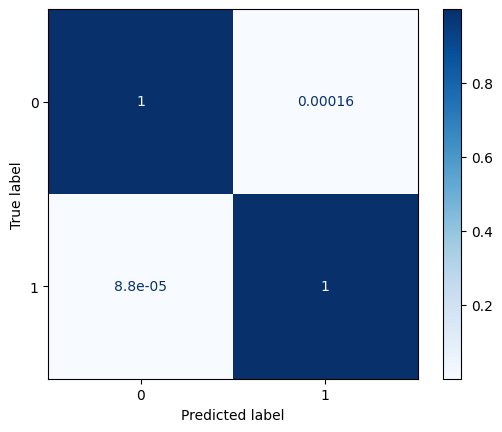

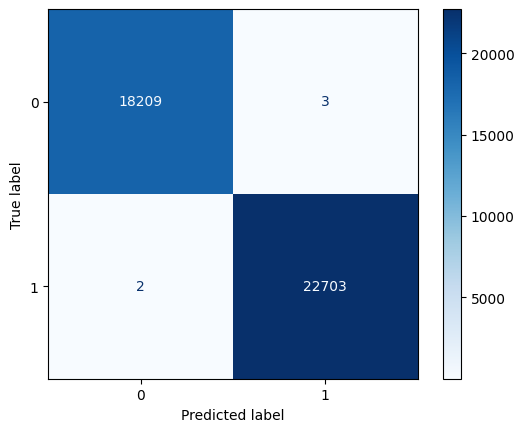

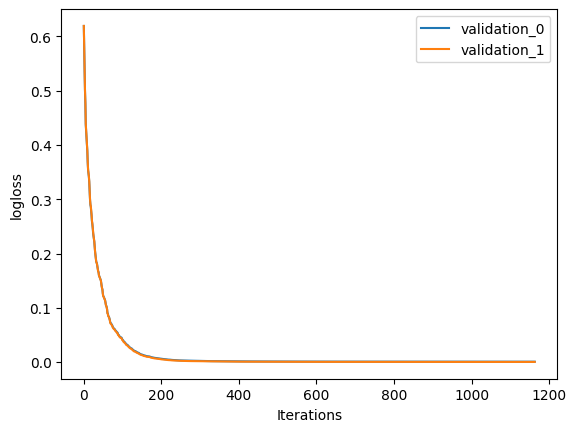

Train-Test-Difference: 0.00012219859716011694
Model Size in Bytes: 		1280684
Model Size in kiloBytes: 	1250.66796875


In [84]:
depth = 4

clf_final = XGBClassifier(objective = "binary:logistic",
                          tree_method = 'exact',
                          n_estimators = bestIterList[depth-1],
                          max_depth = depth
                          )

clf_final.fit(xtrain,ytrain,
              eval_set=ev_both,
              verbose = 0
              )

plotReport(clf_final)
plotGeneralizationCurves(clf_final)
checkOverfitting(clf_final)
print(f'Model Size in Bytes: \t\t{ubjSizeList[depth-1]}')
print(f'Model Size in kiloBytes: \t{ubjSizeList_kB[depth-1]}')

In [87]:
print(f'Model Size in Bytes: \t\t{jsonSizeList[depth-1]}')
print(f'Model Size in kiloBytes: \t{jsonSizeList[depth-1]/1024}')

print(f'Model Size in Bytes: \t\t{jsonSizeList[14]}')

Model Size in Bytes: 		1279235
Model Size in kiloBytes: 	1249.2529296875
Model Size in Bytes: 		775376


# Sonstiges/Eingestellt

## Pulling data from UCI-Repo

In [77]:
# from ucimlrepo import fetch_ucirepo 

# # fetch dataset 
# secondary_mushroom = fetch_ucirepo(id=848) 
  
# # data (as pandas dataframes) 
# x_mushy = secondary_mushroom.data.features 
# y_mushy = secondary_mushroom.data.targets 